# Sewa Jas & Formal Wear — Training Pipeline (Hybrid Intent Classifier)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports

In [ ]:
import sys
import random
import json
import pickle
import collections
from pathlib import Path
from datetime import date

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    precision_recall_fscore_support,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/src"))
sys.path.insert(0, str(ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/scripts"))

from jas_chatbot.nlu.entity_extractor import EntityExtractor
from jas_chatbot.nlu.intent_classifier import GREETING_INTENTS
from jas_chatbot.preprocessing.text_processor import TextProcessor
from augment_data import augment_pattern

sns.set_style("whitegrid")
random.seed(42)
np.random.seed(42)
RANDOM_STATE = 42
print("sklearn", sklearn.__version__, "| numpy", np.__version__)

sklearn 1.6.1 | numpy 2.0.2


## 2. Build the knowledge-derived files

Dua file turunan dibuat dari data toko sebelum training bisa jalan:
- `data/raw/intents_semantic.json` -- hasil konversi `intents.json` (skema `intent`/`contoh_pertanyaan`) ke skema `tag`/`patterns` yang dipakai pipeline.
- `data/knowledge/entities_katalog.json` -- daftar ukuran & warna yang benar-benar ada di stok, diambil dari `knowledge_base.json`, dipakai `EntityExtractor`.

Kalau kedua file ini sudah ada di repo kamu, sel ini boleh dilewati -- di sini disertakan supaya notebook bisa jalan langsung dari `knowledge_base.json` + `intents.json` mentah.

In [ ]:
with open(ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/data/raw/intents.json", encoding="utf-8") as f:
    _raw = json.load(f)

semantic = {"intents": []}
for it in _raw["intents"]:
    semantic["intents"].append({
        "tag": it["intent"],
        "patterns": it["contoh_pertanyaan"],
        "jawaban_default": it.get("jawaban_default"),
        "context_set": it.get("context_set"),
    })
with open(ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/data/raw/intents_semantic.json", "w", encoding="utf-8") as f:
    json.dump(semantic, f, ensure_ascii=False, indent=2)

with open(ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/data/knowledge/knowledge_base.json", encoding="utf-8") as f:
    kb = json.load(f)

colors, sizes = set(), set()
for cat in kb["produk"].values():
    for v in cat.get("varian_warna", []):
        colors.add(v["warna"])
        for u in v.get("ukuran_tersedia", []):
            sizes.add(str(u))

import re as _re
expanded = set(colors)
for w in list(colors):
    m = _re.match(r"^(.*)\s*\(([^)]+)\)\s*$", w)
    if m:
        expanded.add(m.group(1).strip())
        expanded.add(m.group(2).strip())

entities = {"warna": sorted(expanded, key=len, reverse=True), "ukuran": sorted(sizes, key=len, reverse=True)}
with open(ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/data/knowledge/entities_katalog.json", "w", encoding="utf-8") as f:
    json.dump(entities, f, ensure_ascii=False, indent=2)

print(f"Tags: {len(semantic['intents'])}, total patterns: {sum(len(i['patterns']) for i in semantic['intents'])}")
print(f"Warna terdeteksi: {entities['warna']}")
print(f"Jumlah nilai ukuran unik: {len(entities['ukuran'])}")

Tags: 19, total patterns: 1808
Warna terdeteksi: ['Biru Dongker (Navy)', 'Biru Elektrik', 'Biru Dongker', 'Abu-abu Muda', 'Putih Tulang', 'Abu-abu Tua', 'Coklat Tua', 'Hijau Army', 'Biru Muda', 'Silver', 'Maroon', 'Hitam', 'Cream', 'Navy']
Jumlah nilai ukuran unik: 29


## 3. Load the semantic intent dataset

In [ ]:
with open(ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/data/raw/intents_semantic.json", encoding="utf-8") as f:
    data = json.load(f)

patterns, labels = [], []
for intent in data["intents"]:
    for p in intent["patterns"]:
        patterns.append(p)
        labels.append(intent["tag"])

print(f"Total patterns: {len(patterns)}")
print(f"Classes ({len(set(labels))}):")
for tag, n in collections.Counter(labels).most_common():
    print(f"  {tag:24} {n}")

Total patterns: 1808
Classes (19):
  tanya_ukuran             199
  cara_sewa                198
  tanya_stok_barang        110
  reschedule_pembatalan    102
  tanya_ukuran_celana      100
  tanya_ukuran_sepatu      100
  tanya_warna_jas          100
  tanya_warna_celana       100
  tanya_warna_sepatu       100
  tanya_harga              100
  denda_keterlambatan      100
  tanya_durasi_sewa        100
  cara_bayar               98
  tidak_dikenali           74
  tanya_lokasi_dan_jam     53
  sapaan                   51
  layanan_antar            43
  ucapan_terima_kasih      40
  promo_diskon             40


## 4. Runtime-parity preprocessing

Di saat serving, ukuran/warna yang disebut user diganti placeholder `[UKURAN]`/`[WARNA]` lalu di-stem. Transform yang sama dipakai di sini supaya training match dengan inference.

In [ ]:
extractor = EntityExtractor(ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/data/knowledge/entities_katalog.json")
processor = TextProcessor()

def preprocess(raw: str) -> str:
    neutral = extractor.replace_with_placeholder(raw)
    return processor.preprocess(neutral)

for example in ["ada jas ukuran L?", "celana warna navy ada size 32 gak", "selamat pagi min"]:
    print(f"{example!r:42} -> {preprocess(example)!r}")

'ada jas ukuran L?'                        -> 'ada jas ukuran [ukuran]'
'celana warna navy ada size 32 gak'        -> 'celana warna [warna] ada size [ukuran] gak'
'selamat pagi min'                         -> 'selamat pagi min'


## 5. Train/test split — BEFORE augmentation

Split dulu supaya varian hasil augmentasi dari satu kalimat training tidak pernah bocor ke test set. Stratified per intent.

In [ ]:
p_train, p_test, y_train_lbl, y_test_lbl = train_test_split(
    patterns, labels, test_size=0.2, random_state=RANDOM_STATE, stratify=labels,
)
print(f"Train (pre-aug): {len(p_train)}   Test: {len(p_test)}")

Train (pre-aug): 1446   Test: 362


## 6. Augment the training split only

`augment_pattern` menambah variasi casing/tanda baca, filler sopan ("min"/"kak"), dan typo ringan. Test split tetap mentah.

In [ ]:
aug_patterns, aug_labels = [], []
for pattern, label in zip(p_train, y_train_lbl):
    for variant in augment_pattern(pattern, label):
        aug_patterns.append(variant)
        aug_labels.append(label)

print(f"Train after augmentation: {len(aug_patterns)} "
      f"(x{len(aug_patterns)/len(p_train):.1f})")

X_train_text = [preprocess(p) for p in aug_patterns]
X_test_text  = [preprocess(p) for p in p_test]

label_encoder = LabelEncoder().fit(aug_labels + y_test_lbl)
y_train = label_encoder.transform(aug_labels)
y_test  = label_encoder.transform(y_test_lbl)

Train after augmentation: 4653 (x3.2)


## 7. Feature extraction — dual TF-IDF fit on TRAIN only

In [ ]:
tfidf_main = TfidfVectorizer(
    max_features=2000, ngram_range=(1, 2), min_df=2, max_df=0.9,
    token_pattern=r"\b\w+\b",
)
X_train_main = tfidf_main.fit_transform(X_train_text)
X_test_main  = tfidf_main.transform(X_test_text)

tfidf_greeting = TfidfVectorizer(
    max_features=500, ngram_range=(1, 2), min_df=1, max_df=0.9,
    token_pattern=r"\b\w+\b",
)
X_train_greet = tfidf_greeting.fit_transform(X_train_text)

print(f"Main TF-IDF:     {X_train_main.shape}")
print(f"Greeting TF-IDF: {X_train_greet.shape}")

Main TF-IDF:     (4653, 2000)
Greeting TF-IDF: (4653, 500)


## 8. Stage 1 — binary GreetingDetector

SVM linear untuk memisahkan `sapaan`/`ucapan_terima_kasih` dari intent lain -- dipakai sebagai gate cepat untuk pesan pendek.

In [ ]:
greeting_codes = set(label_encoder.transform(sorted(GREETING_INTENTS)))
y_train_bin = np.array([1 if c in greeting_codes else 0 for c in y_train])

greeting_detector = SVC(kernel="linear", C=1.0, probability=True,
                        class_weight="balanced", random_state=RANDOM_STATE)
greeting_detector.fit(X_train_greet, y_train_bin)
print("GreetingDetector trained "
      f"(greeting={int(y_train_bin.sum())}, non-greeting={int((y_train_bin==0).sum())})")

GreetingDetector trained (greeting=211, non-greeting=4442)


## 9. Stage 2 — main semantic classifier

SVM linear 20-kelas dengan `class_weight="balanced"` dan probability estimates (dipakai untuk fallback berbasis confidence).

In [ ]:
main_svm = SVC(kernel="linear", C=1.0, probability=True,
               class_weight="balanced", random_state=RANDOM_STATE)
main_svm.fit(X_train_main, y_train)

y_pred = main_svm.predict(X_test_main)
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Held-out test accuracy: {acc*100:.2f}%")
print(f"Macro F1-score:         {macro_f1*100:.2f}%")

Held-out test accuracy: 89.78%
Macro F1-score:         89.94%


## 9b. Cross-validation (trustworthy, split-independent)

Split 80/20 tunggal hanya menyisakan ~8-11 sampel test per intent, jadi angka per-kelasnya agak noisy. Stratified 5-fold CV -- augmentasi dilakukan **di dalam** tiap fold supaya varian tidak bocor ke validation -- memberi rata-rata +/- std yang lebih bisa dipercaya.

In [ ]:
from train import cross_validate

_ = cross_validate(patterns, labels, extractor, processor, n_splits=5)

  Fold 1/5:  acc=88.67%   macro-F1=87.03%
  Fold 2/5:  acc=90.33%   macro-F1=90.66%
  Fold 3/5:  acc=87.85%   macro-F1=86.96%
  Fold 4/5:  acc=88.64%   macro-F1=87.23%
  Fold 5/5:  acc=86.43%   macro-F1=84.92%

CV accuracy:  88.38% +/- 1.27%
CV macro-F1:  87.36% +/- 1.85%


## 10. Classification report (held-out test)

In [ ]:
print(classification_report(
    y_test, y_pred, target_names=label_encoder.classes_,
    digits=3, zero_division=0,
))

                       precision    recall  f1-score   support

           cara_bayar      0.826     0.950     0.884        20
            cara_sewa      0.846     0.825     0.835        40
  denda_keterlambatan      1.000     0.800     0.889        20
        layanan_antar      1.000     0.875     0.933         8
         promo_diskon      0.800     1.000     0.889         8
reschedule_pembatalan      0.850     0.850     0.850        20
               sapaan      0.909     1.000     0.952        10
    tanya_durasi_sewa      0.909     1.000     0.952        20
          tanya_harga      0.889     0.800     0.842        20
 tanya_lokasi_dan_jam      0.750     0.818     0.783        11
    tanya_stok_barang      1.000     0.864     0.927        22
         tanya_ukuran      0.950     0.950     0.950        40
  tanya_ukuran_celana      0.864     0.950     0.905        20
  tanya_ukuran_sepatu      0.950     0.950     0.950        20
   tanya_warna_celana      0.950     0.950     0.950  

## 11. Confusion matrix

Row-normalised (kiri) supaya kelas dengan jumlah sampel banyak tidak mendominasi skala warna, plus raw-count untuk kelas minoritas saja (kanan).

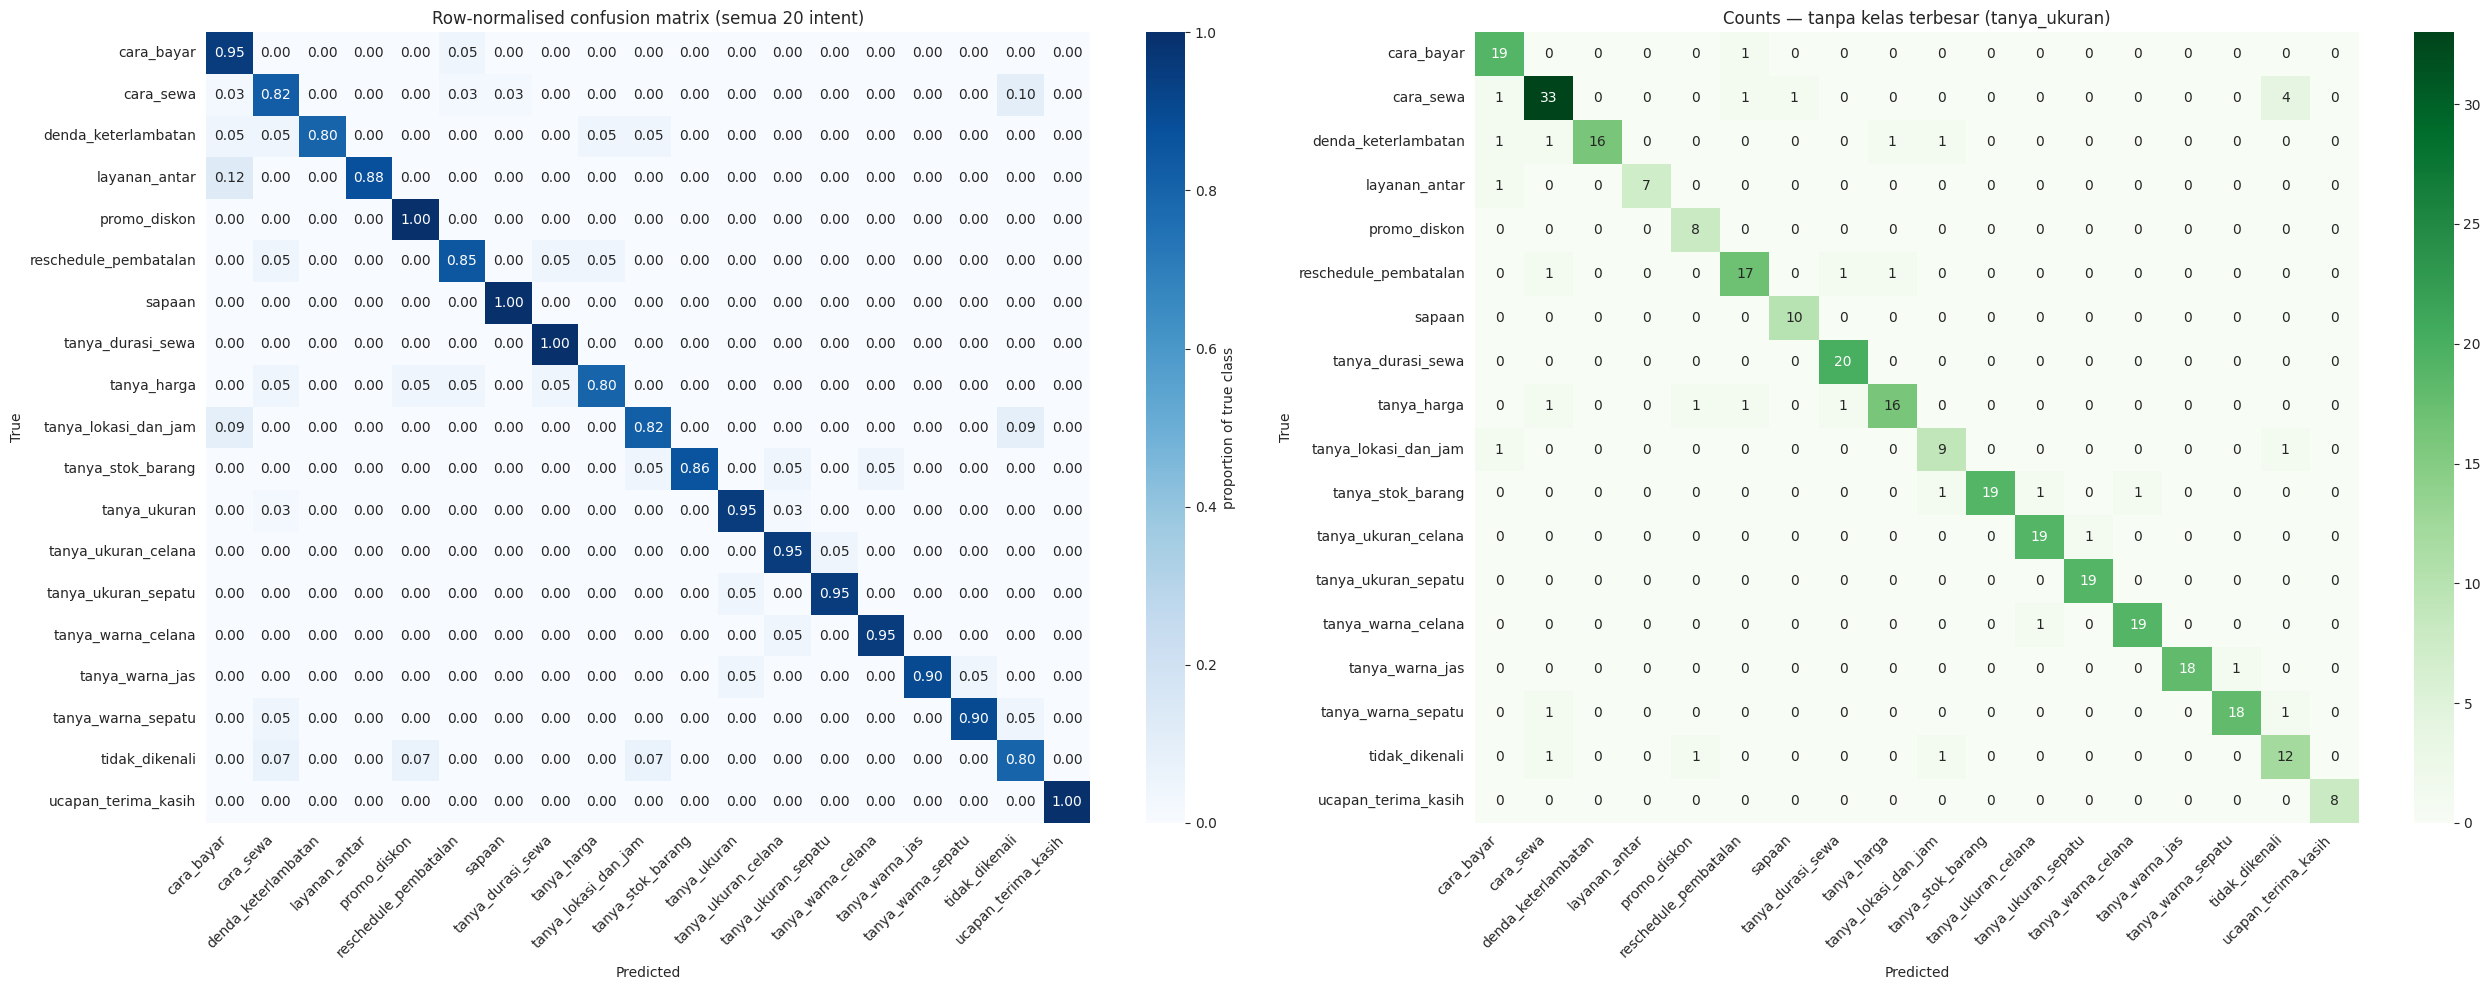

In [ ]:
labels_idx = list(range(len(label_encoder.classes_)))
names = label_encoder.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels_idx)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

biggest = collections.Counter(labels).most_common(1)[0][0]
minority = [i for i, c in enumerate(names) if c != biggest]
cm_min = confusion_matrix(y_test, y_pred, labels=minority)
names_min = [names[i] for i in minority]

fig, axes = plt.subplots(1, 2, figsize=(26, 10))

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=names, yticklabels=names, ax=axes[0],
            cbar_kws={"label": "proportion of true class"})
axes[0].set_title("Row-normalised confusion matrix (semua 20 intent)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_min, annot=True, fmt="d", cmap="Greens",
            xticklabels=names_min, yticklabels=names_min, ax=axes[1])
axes[1].set_title(f"Counts — tanpa kelas terbesar ({biggest})")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()

## 12. Per-class F1-score

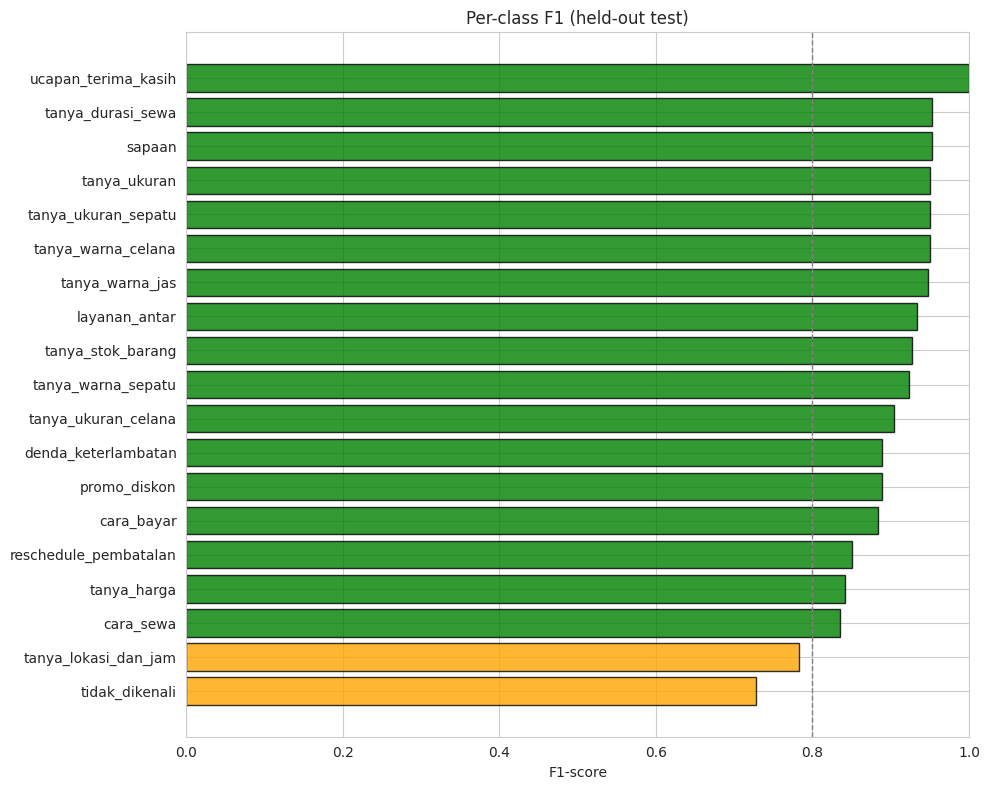

In [ ]:
prec, rec, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=range(len(label_encoder.classes_)), zero_division=0,
)
order = np.argsort(f1)
plt.figure(figsize=(10, 8))
colors_ = ["green" if v >= 0.8 else "orange" if v >= 0.5 else "red" for v in f1[order]]
plt.barh(range(len(order)), f1[order], color=colors_, alpha=0.8, edgecolor="black")
plt.yticks(range(len(order)), [label_encoder.classes_[i] for i in order])
plt.axvline(0.8, color="gray", ls="--", lw=1)
plt.xlabel("F1-score"); plt.xlim(0, 1.0)
plt.title("Per-class F1 (held-out test)")
plt.tight_layout(); plt.show()

## 13. Persist artifacts

Simpan lima artifact yang di-load bot, plus `metadata.json`. Untuk produksi lebih baik jalankan `scripts/train.py` (mengulang langkah yang sama secara non-interaktif).

In [ ]:
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

def dump(obj, name):
    with open(MODEL_DIR / name, "wb") as f:
        pickle.dump(obj, f)

dump(tfidf_main,        "tfidf_vectorizer.pickle")
dump(tfidf_greeting,    "tfidf_greeting.pickle")
dump(main_svm,          "svm_model.pkl")
dump(greeting_detector, "greeting_detector.pkl")
dump(label_encoder,     "label_encoder.pickle")

metadata = {
    "trained_on": str(date.today()),
    "input_dataset": "data/raw/intents_semantic.json",
    "sklearn_version": sklearn.__version__,
    "numpy_version": np.__version__,
    "classes": list(label_encoder.classes_),
    "n_classes": len(label_encoder.classes_),
    "train_samples_pre_aug": len(p_train),
    "train_samples_post_aug": len(aug_patterns),
    "test_samples": len(p_test),
    "test_accuracy": round(float(acc), 4),
    "test_macro_f1": round(float(macro_f1), 4),
    "random_state": RANDOM_STATE,
}
with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("Saved artifacts + metadata to", MODEL_DIR)

Saved artifacts + metadata to /content/models


## 14. Smoke test — full hybrid pipeline

Load artifact yang tersimpan lewat `NLUPipeline` penuh untuk memastikan perilaku end-to-end (confidence fallback + entity extraction) sudah benar.

In [ ]:
import re

ENTITIES_KATALOG_PATH = ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/data/knowledge/entities_katalog.json"
with open(ENTITIES_KATALOG_PATH, encoding="utf-8") as f:
    _katalog = json.load(f)

def extract_all_entities(text: str) -> dict:
    """Scan teks buat SEMUA entity (warna + ukuran) sekaligus, gak berhenti di satu entity aja."""
    text_l = text.lower()
    found = {}
    for warna in _katalog["warna"]:
        if warna.lower() in text_l:
            found["warna"] = warna
            break
    for ukuran in _katalog["ukuran"]:
        if re.search(rf"\b{re.escape(ukuran.lower())}\b", text_l):
            found["ukuran"] = ukuran
            break
    return found

def detect_jenis_barang(text: str) -> str | None:
    text_l = text.lower()
    for jenis in ("jas", "celana", "sepatu"):
        if jenis in text_l:
            return jenis
    return None

def cari_stok(kb: dict, jenis_barang: str, warna: str = None, ukuran: str = None):
    """Query stok dari knowledge_base.json. Return list of (warna, ukuran, jumlah)."""
    produk = kb.get("produk", {}).get(jenis_barang)
    if not produk:
        return []
    hasil = []
    for v in produk.get("varian_warna", []):
        if warna and warna.lower() not in v["warna"].lower():
            continue
        stok_map = v.get("stok_per_ukuran", {})
        if ukuran:
            u = ukuran.upper()
            if u in stok_map:
                hasil.append((v["warna"], u, stok_map[u]))
        else:
            for u, jumlah in stok_map.items():
                hasil.append((v["warna"], u, jumlah))
    return hasil

def generate_jawaban(r, teks_asli: str, data: dict, kb: dict) -> str:
    # Fallback kalau confidence terlalu rendah -- jangan pede jawab yang salah
    if r.confidence < _S.intent_confidence_threshold:
        return "Maaf, aku kurang yakin maksudnya apa. Boleh dijelasin lebih detail?"

    if r.intent == "tanya_lokasi_dan_jam":
        info = kb.get("informasi_toko", {})
        jam = info.get("jam_operasional", "-")
        alamat = info.get("alamat", "-")
        return f"Tokonya buka {jam}. Alamatnya di {alamat}."

    if r.intent == "tanya_stok_barang":
        entitas = extract_all_entities(teks_asli)
        jenis = detect_jenis_barang(teks_asli)
        if jenis:
            hasil = cari_stok(kb, jenis, entitas.get("warna"), entitas.get("ukuran"))
            if hasil:
                if len(hasil) == 1:
                    warna, ukuran, jumlah = hasil[0]
                    return f"Stok {jenis} warna {warna} ukuran {ukuran} tinggal {jumlah} unit."
                lines = [f"- {w}, ukuran {u}: {j} unit" for w, u, j in hasil]
                return f"Stok {jenis} yang tersedia:\n" + "\n".join(lines)
        return "Boleh sebutin jenis barang, warna, dan ukurannya biar aku cekin stoknya?"

    # Intent lain tetap pakai jawaban_default statis seperti biasa
    return next((i["jawaban_default"] for i in data["intents"] if i["tag"] == r.intent), None)

In [ ]:
from jas_chatbot.nlu.pipeline import NLUPipeline

def is_likely_gibberish(text, vectorizer, oov_ratio_threshold=0.7):
    """
    Cek rasio kata yang tidak dikenal (out-of-vocabulary) oleh vectorizer.
    Independen dari confidence -- solusi buat kasus dimana teks pendek
    yang valid (misal 'hai') punya confidence sama rendahnya dengan gibberish.
    """
    tokens = text.strip().lower().split()
    if not tokens:
        return True
    known = sum(1 for t in tokens if t in vectorizer.vocabulary_)
    oov_ratio = 1 - (known / len(tokens))
    return oov_ratio >= oov_ratio_threshold


class _S:
    model_dir = ROOT / "models"
    kecamatan_path = ROOT / "/content/drive/MyDrive/magang/chrbot/cht1/v4/jas-chatbot/data/knowledge/entities_katalog.json"
    greeting_confidence_threshold = 0.7
    word_count_threshold = 3
    intent_confidence_threshold = 0.65  # turunkan lagi, jangan 0.85

nlu = NLUPipeline.from_settings(_S)

# Load the TF-IDF vectorizer directly for the smoke test, as NLUPipeline does not expose it
with open(_S.model_dir / "tfidf_vectorizer.pickle", "rb") as f:
    tfidf_vectorizer_for_gibberish_check = pickle.load(f)

tests = [
    "halo", "hai", "min pagi", "ada jas ukuran L gak", "celana warna navy ada?",
    "gimana cara sewa nya", "telat kena denda berapa", "lagi ada promo gak min",
    "sepatu ukuran 42 ready?", "asdkjh qweqwe zxcvb",
]
for t in tests:
    r = nlu.understand(t)
    ent = ", ".join(f"{k}:{v}" for k, v in r.entities.items() if v) or "-"

    # gabungan dua sinyal: confidence rendah ATAU teksnya OOV-heavy
    low_conf = r.confidence < _S.intent_confidence_threshold
    gibberish = is_likely_gibberish(t, tfidf_vectorizer_for_gibberish_check)
    tampil_intent = "tidak_dikenali" if (low_conf or gibberish) else r.intent

    print(f"{t:34} -> {tampil_intent:24} ({r.confidence:.2f})  entity={ent}")

halo                               -> sapaan                   (1.00)  entity=-
hai                                -> sapaan                   (0.75)  entity=-
min pagi                           -> sapaan                   (0.75)  entity=-
ada jas ukuran L gak               -> tanya_ukuran             (0.98)  entity=ukuran:l
celana warna navy ada?             -> tanya_warna_celana       (1.00)  entity=warna:navy
gimana cara sewa nya               -> cara_sewa                (1.00)  entity=-
telat kena denda berapa            -> denda_keterlambatan      (1.00)  entity=-
lagi ada promo gak min             -> promo_diskon             (0.94)  entity=-
sepatu ukuran 42 ready?            -> tanya_ukuran_sepatu      (1.00)  entity=ukuran:42
asdkjh qweqwe zxcvb                -> tidak_dikenali           (0.75)  entity=-


In [ ]:
import re

# Bangun vocabulary dari semua pattern training yang ada
_VOCAB = set()
for intent in data["intents"]:
    for pattern in intent["patterns"]:
        _VOCAB.update(re.findall(r"\w+", pattern.lower()))

def is_likely_gibberish(text, vocab=_VOCAB, oov_ratio_threshold=0.7):
    """
    Cek rasio kata yang gak dikenal (out-of-vocabulary).
    Ini independen dari confidence model, jadi bisa nangkep gibberish
    walau confidence-nya kebetulan mirip sama sapaan pendek yang valid.
    """
    tokens = re.findall(r"\w+", text.lower())
    if not tokens:
        return True
    known = sum(1 for t in tokens if t in vocab)
    oov_ratio = 1 - (known / len(tokens))
    return oov_ratio >= oov_ratio_threshold


while True:
    teks = input("Kamu: ")
    if teks.strip().lower() in ("exit", "keluar", "quit"):
        break

    r = nlu.understand(teks)
    ent = ", ".join(f"{k}:{v}" for k, v in r.entities.items() if v) or "-"

    # kalau teksnya OOV-heavy (gibberish), paksa jadi tidak_dikenali
    # terlepas dari berapa pun confidence yang dikeluarkan model
    if is_likely_gibberish(teks):
        r.intent = "tidak_dikenali"
        r.confidence = 0.0

    jawaban = generate_jawaban(r, teks, data, kb)
    print(f"Bot [{r.intent}, conf={r.confidence:.2f}, entity={ent}]: {jawaban}\n")

Kamu: quit
